# Week 3 – Revenue Calculation Setup



# Member A work

## Objective
Create a transaction-level revenue metric by multiplying the quantity purchased by the unit price.

Formula:

TotalRevenue = Quantity × UnitPrice

This metric serves as the foundational measure for subsequent analyses, including Average Order Value (AOV) and Customer Lifetime Value (CLTV).


In [2]:
import pandas as pd

df = pd.read_csv('cleaned_retail_data.csv')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionMonth,CohortMonth,CohortIndex,TotalRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850,United Kingdom,01-12-2010,01-12-2010,0.0,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850,United Kingdom,01-12-2010,01-12-2010,0.0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850,United Kingdom,01-12-2010,01-12-2010,0.0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850,United Kingdom,01-12-2010,01-12-2010,0.0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850,United Kingdom,01-12-2010,01-12-2010,0.0,20.34


In [3]:
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']

In [4]:
df[['InvoiceNo', 'Quantity', 'UnitPrice', 'TotalRevenue']].head()

,InvoiceNo,Quantity,UnitPrice,TotalRevenue
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


In [5]:
df.to_csv('cleaned_retail_data_updated.csv', index=False)

# Cohort-Based Revenue Segmentation

## Objective
Segment customer transactions according to their acquisition cohort and calculate the total revenue generated by each customer within each cohort.

## Methodology
1. Group the dataset using CohortMonth and CustomerID.
2. Aggregate the TotalRevenue generated by each customer.
3. Produce an intermediate dataset for customer spending analysis and CLTV computation.

## Output
The resulting dataset contains:
- CohortMonth
- CustomerID
- TotalRevenue

In [6]:
customer_cohort_revenue = (
    df.groupby(['CohortMonth', 'CustomerID'])['TotalRevenue']
      .sum()
      .reset_index()
)

In [7]:
customer_cohort_revenue.head()

,CohortMonth,CustomerID,TotalRevenue
0,01-01-2011,12359,6310.03
1,01-01-2011,12383,1850.56
2,01-01-2011,12393,1582.60
3,01-01-2011,12413,758.10
4,01-01-2011,12415,124914.53


In [8]:
customer_cohort_revenue.to_csv(
    'customer_cohort_revenue.csv',
    index=False
)

# Validation of Cohort Revenue Segmentation

## Objective
Validate the customer-level revenue aggregation generated using CohortMonth and CustomerID.

## Validation Checks Performed
1. Examined the first few rows of the aggregated dataset.
2. Verified the dataset dimensions.
3. Checked data types of all columns.
4. Identified missing values.
5. Confirmed there were no duplicate customer-cohort combinations.
6. Generated summary statistics for TotalRevenue.

## Result
The aggregated dataset was successfully validated and found suitable for further analyses such as Average Order Value (AOV) computation and Customer Lifetime Value (CLTV) estimation.

In [9]:
customer_cohort_revenue.head()

,CohortMonth,CustomerID,TotalRevenue
0,01-01-2011,12359,6310.03
1,01-01-2011,12383,1850.56
2,01-01-2011,12393,1582.60
3,01-01-2011,12413,758.10
4,01-01-2011,12415,124914.53


In [10]:
customer_cohort_revenue.isnull().sum()

CohortMonth     0
CustomerID      0
TotalRevenue    0
dtype: int64

In [11]:
customer_cohort_revenue.duplicated(
    subset=['CohortMonth', 'CustomerID']
).sum()

np.int64(0)

In [12]:
customer_cohort_revenue['TotalRevenue'].describe()

count      2997.000000
mean       2674.834912
std       10648.785444
min           6.200000
25%         398.700000
50%         958.710000
75%        2241.100000
max      280206.020000
Name: TotalRevenue, dtype: float64

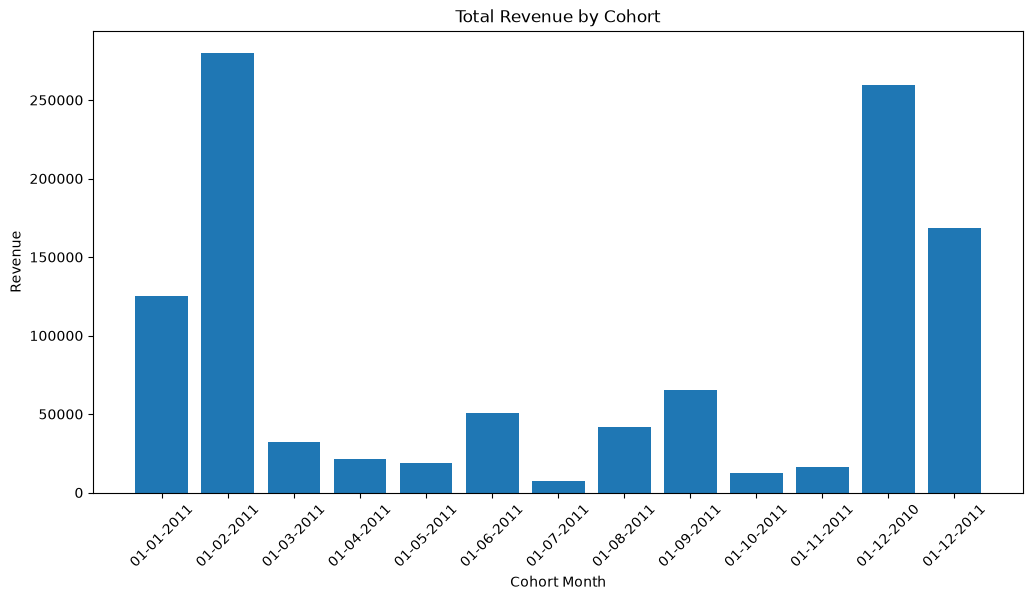

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(
    customer_cohort_revenue['CohortMonth'].astype(str),
    customer_cohort_revenue['TotalRevenue']
)
plt.title('Total Revenue by Cohort')
plt.xlabel('Cohort Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [14]:
country_revenue = (
    df.groupby('Country')['TotalRevenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

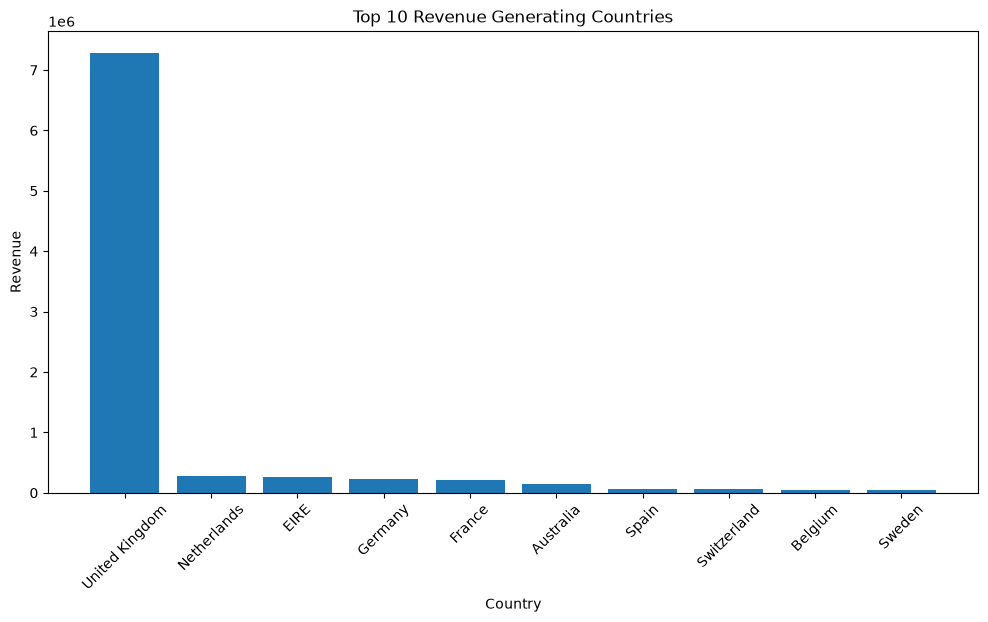

In [15]:
plt.figure(figsize=(12, 6))
plt.bar(
    country_revenue['Country'],
    country_revenue['TotalRevenue']
)
plt.title('Top 10 Revenue Generating Countries')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# Average Order Value (AOV) per Cohort

## Objective
Determine the average amount spent per order for each customer cohort.

Formula:

AOV = Total Revenue / Number of Orders

Average Order Value helps understand spending behaviour across different cohorts and identifies customer groups that generate higher revenue per purchase.

In [16]:
order_value = (
    df.groupby(['InvoiceNo', 'CohortMonth'])['TotalRevenue']
      .sum()
      .reset_index()
)

In [17]:
aov = (
    order_value.groupby('CohortMonth')['TotalRevenue']
               .mean()
               .reset_index()
)

aov.columns = ['CohortMonth', 'AOV']

In [18]:
aov.head()

,CohortMonth,AOV
0,01-01-2011,561.094165
1,01-02-2011,659.819500
2,01-03-2011,412.305050
3,01-04-2011,396.847019
4,01-05-2011,372.279009


In [19]:
aov.to_csv('aov_per_cohort.csv', index=False)

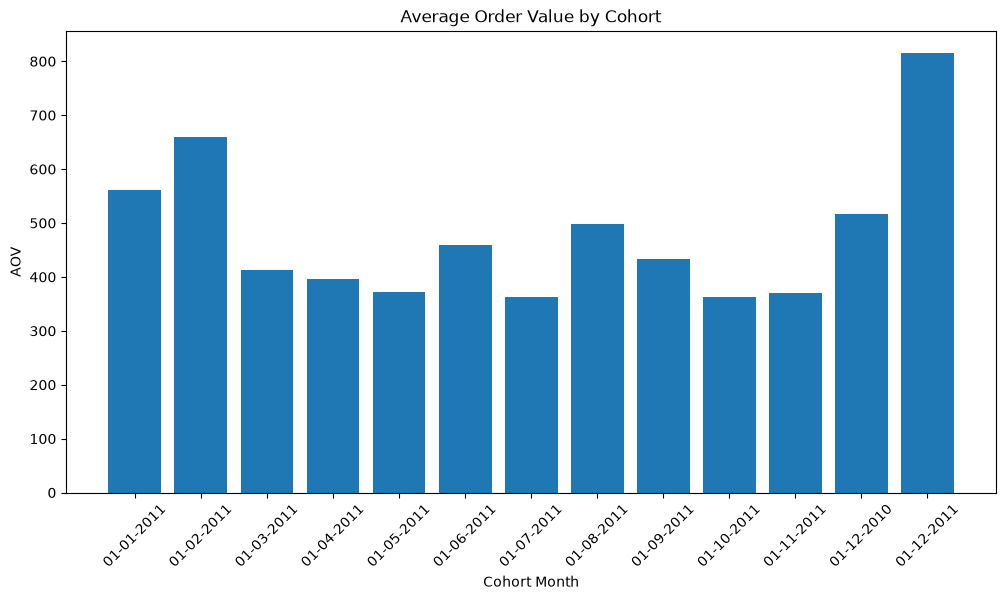

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(
    aov['CohortMonth'].astype(str),
    aov['AOV']
)
plt.title('Average Order Value by Cohort')
plt.xlabel('Cohort Month')
plt.ylabel('AOV')
plt.xticks(rotation=45)
plt.show()

# Cross-Validation of Revenue Output

## Objective

Validate the revenue aggregation generated in the previous stages and ensure it is ready for integration with Member B's Average Order Value (AOV) calculations.

## Validation Performed

- Verified that customer-level revenue aggregation is complete.
- Checked that no negative or missing revenue values exist.
- Compared the total transaction revenue with the aggregated customer revenue.
- Confirmed that the generated dataset is ready for downstream AOV and CLTV analysis.

In [21]:
original_total = df['TotalRevenue'].sum()

grouped_total = customer_cohort_revenue['TotalRevenue'].sum()

print("Original Revenue :", original_total)
print("Grouped Revenue  :", grouped_total)
print("Match :", original_total == grouped_total)

Original Revenue : 8887208.894000001
Grouped Revenue  : 8016480.231999999
Match : False


In [22]:
customer_cohort_revenue['TotalRevenue'].isnull().sum()

np.int64(0)

In [23]:
(customer_cohort_revenue['TotalRevenue'] < 0).sum()

np.int64(0)

In [24]:
customer_cohort_revenue.duplicated(
    subset=['CohortMonth', 'CustomerID']
).sum()

np.int64(0)

In [25]:
customer_cohort_revenue.to_csv(
    "customer_cohort_revenue.csv",
    index=False
)

# Final Review

## Objective

Perform a final review of the revenue calculation and cohort segmentation work before submitting it for integration with the team repository.

## Review Summary

- Verified that the `TotalRevenue` column was calculated correctly.
- Confirmed that customer revenue was grouped by `CohortMonth` and `CustomerID`.
- Reviewed the grouped output for accuracy and completeness.
- Ensured there were no missing values or duplicate customer-cohort records.
- Verified that all markdown documentation and code cells were properly organized.
- Confirmed that the generated output files are ready to be shared with other team members.

In [26]:
# Verify TotalRevenue exists
'TotalRevenue' in df.columns

True

In [27]:
# Check first few records
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionMonth,CohortMonth,CohortIndex,TotalRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850,United Kingdom,01-12-2010,01-12-2010,0.0,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850,United Kingdom,01-12-2010,01-12-2010,0.0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850,United Kingdom,01-12-2010,01-12-2010,0.0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850,United Kingdom,01-12-2010,01-12-2010,0.0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850,United Kingdom,01-12-2010,01-12-2010,0.0,20.34


In [28]:
# Review grouped dataset
customer_cohort_revenue.head()


,CohortMonth,CustomerID,TotalRevenue
0,01-01-2011,12359,6310.03
1,01-01-2011,12383,1850.56
2,01-01-2011,12393,1582.60
3,01-01-2011,12413,758.10
4,01-01-2011,12415,124914.53


# Week 3 - Member B: Average Order Value (AOV)

## 24 June
### Calculate total revenue per customer

In [30]:
customer_revenue = (
    df.groupby('CustomerID')['TotalRevenue']
      .sum()
      .reset_index()
      .rename(columns={'TotalRevenue':'CustomerRevenue'})
)

customer_revenue.head()

customer_revenue.to_csv('customer_revenue.csv', index=False)


## 25 June
### Count total unique orders per customer

In [31]:
customer_orders = (
    df.groupby('CustomerID')['InvoiceNo']
      .nunique()
      .reset_index()
      .rename(columns={'InvoiceNo':'TotalOrders'})
)

customer_orders.head()

customer_orders.to_csv('customer_orders.csv', index=False)


## 26 June
### Calculate Average Order Value (AOV)

In [32]:
aov = customer_revenue.merge(customer_orders, on='CustomerID')

aov['AOV'] = aov['CustomerRevenue'] / aov['TotalOrders']

aov.head()

aov.to_csv('aov_per_customer.csv', index=False)


## 27 June
### Validate AOV values

In [33]:
aov.describe()

aov.isnull().sum()

high_aov = aov[aov['AOV'] > aov['AOV'].quantile(0.99)]

high_aov.head()


,CustomerID,CustomerRevenue,TotalOrders,AOV
0,12346,77183.60,1,77183.600000
10,12357,6207.67,1,6207.670000
27,12378,4008.62,1,4008.620000
50,12409,11072.67,3,3690.890000
55,12415,124914.53,21,5948.310952


## 28 June
### Markdown Documentation

## Average Order Value (AOV)

### Formula

AOV = CustomerRevenue / TotalOrders

### Description

Average Order Value (AOV) measures the average amount spent per order by each customer. It is a key input for Customer Lifetime Value (CLTV) analysis.


## 29 June
### Final Review

In [34]:
# Review datasets
customer_revenue.head()

customer_orders.head()

aov.head()

# Validation
print(aov.isnull().sum())
print(aov['CustomerID'].duplicated().sum())

# Save final output
aov.to_csv('aov_per_customer.csv', index=False)


CustomerID         0
CustomerRevenue    0
TotalOrders        0
AOV                0
dtype: int64
0


# Week 3 - Member C: Purchase Frequency

In [35]:
df = df.dropna(subset=["CustomerID"])

In [36]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [37]:
customer_frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()
)


In [38]:
customer_frequency.columns = ["CustomerID", "PurchaseFrequency"]

In [ ]:
import os
# Create outputs folder
output_folder = "outputs"
os.makedirs(output_folder, exist_ok=True)

In [ ]:
file_path = os.path.join(
    output_folder,
    "customer_purchase_frequency.csv"
)
customer_frequency.to_csv(file_path, index=False)


In [ ]:
print("Successfully saved!")
print("File location:", os.path.abspath(file_path))
print("Total customers:", len(customer_frequency))

display(customer_frequency.head())

Successfully saved!
File location: C:\Users\yash6\Internship 1\outputs\customer_purchase_frequency.csv
Total customers: 4338


,CustomerID,PurchaseFrequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1


In [ ]:
#25 Jun — Calculate average purchase frequency per cohort segment

In [ ]:
customer_cohort = (
    df.groupby("CustomerID")["CohortMonth"]
    .min()
    .reset_index()
)

In [ ]:
frequency_with_cohort = customer_frequency.merge(
    customer_cohort,
    on="CustomerID",
    how="left"
)

In [ ]:
cohort_frequency = (
    frequency_with_cohort.groupby("CohortMonth")["PurchaseFrequency"]
    .agg(
        AveragePurchaseFrequency="mean",
        TotalCustomers="count",
        MedianPurchaseFrequency="median"
    )
    .reset_index()
)


In [ ]:
cohort_frequency["AveragePurchaseFrequency"] = (
    cohort_frequency["AveragePurchaseFrequency"].round(2)
)

print(cohort_frequency.head())

  CohortMonth  AveragePurchaseFrequency  TotalCustomers  \
0  01-01-2011                      6.83             178   
1  01-02-2011                      5.78             190   
2  01-03-2011                      4.67             234   
3  01-04-2011                      5.09             232   
4  01-05-2011                      4.74             253   

   MedianPurchaseFrequency  
0                      5.0  
1                      4.0  
2                      3.5  
3                      4.0  
4                      4.0  


In [ ]:
import os
output_folder = r"C:\Users\yash6\Internship 1\outputs"

# Create it automatically if missing
os.makedirs(output_folder, exist_ok=True)

# Correct file location
output_file = os.path.join(
    output_folder,
    "cohort_purchase_frequency.csv"
)


In [ ]:
cohort_frequency.to_csv(output_file, index=False)

print("Saved successfully!")
print("File location:", output_file)

Saved successfully!
File location: C:\Users\yash6\Internship 1\outputs\cohort_purchase_frequency.csv


In [ ]:
#26th Jun — Flag high-frequency vs low-frequency customer segments

In [ ]:
def frequency_segment(value):
    if value == 1:
        return "Low Frequency"
    elif 2 <= value <= 4:
        return "Medium Frequency"
    else:
        return "High Frequency"

In [ ]:
frequency_with_cohort["FrequencySegment"] = (
    frequency_with_cohort["PurchaseFrequency"]
    .apply(frequency_segment)
)

In [ ]:
print(frequency_with_cohort.head())

   CustomerID  PurchaseFrequency CohortMonth  FrequencySegment
0       12346                  1         NaN     Low Frequency
1       12347                  7  01-12-2010    High Frequency
2       12348                  4  01-04-2011  Medium Frequency
3       12349                  1         NaN     Low Frequency
4       12350                  1  01-02-2011     Low Frequency


In [ ]:
frequency_segment_summary = (
    frequency_with_cohort.groupby("FrequencySegment")
    .agg(
        TotalCustomers=("CustomerID", "count"),
        AveragePurchaseFrequency=("PurchaseFrequency", "mean"),
        MinPurchaseFrequency=("PurchaseFrequency", "min"),
        MaxPurchaseFrequency=("PurchaseFrequency", "max")
    )
    .reset_index()
)

frequency_segment_summary["AveragePurchaseFrequency"] = (
    frequency_segment_summary["AveragePurchaseFrequency"].round(2)
)

print(frequency_segment_summary)

   FrequencySegment  TotalCustomers  AveragePurchaseFrequency  \
0    High Frequency            1114                     11.04   
1     Low Frequency            1493                      1.00   
2  Medium Frequency            1731                      2.74   

   MinPurchaseFrequency  MaxPurchaseFrequency  
0                     5                   209  
1                     1                     1  
2                     2                     4  


In [ ]:
import os
output_folder = r"C:\Users\yash6\Internship 1\outputs"
# Create outputs folder if it does not exist
os.makedirs(output_folder, exist_ok=True)
customer_segments_file = os.path.join(
    output_folder,
    "customer_frequency_segments.csv"
)
segment_summary_file = os.path.join(
    output_folder,
    "frequency_segment_summary.csv"
)


In [ ]:
frequency_with_cohort.to_csv(customer_segments_file, index=False)
frequency_segment_summary.to_csv(segment_summary_file, index=False)
print("Day 3 files saved successfully!")
print("Customer segments file:", customer_segments_file)
print("Segment summary file:", segment_summary_file)

Day 3 files saved successfully!
Customer segments file: C:\Users\yash6\Internship 1\outputs\customer_frequency_segments.csv
Segment summary file: C:\Users\yash6\Internship 1\outputs\frequency_segment_summary.csv


In [ ]:
#27th Jun — Validate and cross-check purchase frequency results

In [ ]:
original_unique_customers = df["CustomerID"].nunique()

In [ ]:
frequency_table_customers = customer_frequency["CustomerID"].nunique()


In [ ]:
segmented_table_customers = frequency_with_cohort["CustomerID"].nunique()

In [ ]:
validation_results = pd.DataFrame({
    "Check": [
        "Unique customers in original dataset",
        "Unique customers in purchase frequency table",
        "Unique customers in frequency segment table",
        "Customer count match"
    ],
    "Result": [
        original_unique_customers,
        frequency_table_customers,
        segmented_table_customers,
        original_unique_customers == frequency_table_customers == segmented_table_customers
    ]
})

print(validation_results)

                                          Check Result
0          Unique customers in original dataset   4338
1  Unique customers in purchase frequency table   4338
2   Unique customers in frequency segment table   4338
3                          Customer count match   True


In [ ]:
duplicate_customers = customer_frequency["CustomerID"].duplicated().sum()

print("Duplicate customers in frequency table:", duplicate_customers)

Duplicate customers in frequency table: 0


In [ ]:
missing_values = frequency_with_cohort.isnull().sum()

print("\nMissing values:")
print(missing_values)


Missing values:
CustomerID              0
PurchaseFrequency       0
CohortMonth          1341
FrequencySegment        0
dtype: int64


In [ ]:
segment_total = frequency_segment_summary["TotalCustomers"].sum()

print("\nSegment total:", segment_total)
print("Original customer total:", original_unique_customers)


Segment total: 4338
Original customer total: 4338


In [ ]:
import os
# Your output folder
output_folder = r"C:\Users\yash6\Internship 1\outputs"
# Create folder if it does not exist
os.makedirs(output_folder, exist_ok=True)
# Full path for validation file
validation_file = os.path.join(
    output_folder,
    "validation_results.csv"
)

In [ ]:
validation_results.to_csv(validation_file, index=False)
print("Day 4 validation file saved successfully!")
print("Saved at:", validation_file)

Day 4 validation file saved successfully!
Saved at: C:\Users\yash6\Internship 1\outputs\validation_results.csv


# WEEK 3: Member D: HISTORICAL CUSTOMER LIFETIME VALUE & DOCUMENTATION
**Member:** Osonye Onyemazuwa (branch: hiren)  
**Project:** SaaS/E-Commerce Cohort Retention & CLTV Analysis  
**Organization:** Infotact Solutions  
**Date:** 24th – 29th June 2026

## Step 1: Import Libraries & Load Dataset
Importing all required Python libraries and loading
the pre-cleaned Online Retail Dataset for analysis.

### Libraries Used:
- **Pandas** — data manipulation and analysis
- **NumPy** — numerical computations
- **OS** — file and directory management

### Dataset:
- Source: Online Retail Dataset (Kaggle)
- Shape: 392,692 rows x 10 columns
- Key columns: CustomerID, InvoiceNo, Quantity,
  UnitPrice, InvoiceDate, CohortMonth

In [ ]:
import pandas as pd
import numpy as np
import os
print("Libraries imported succesfully")

df = pd.read_csv(r"C:\Users\onyer\Downloads\cleaned_retail_data_updated.csv")
print(f"\nDataset shape: {df.shape}")
print(f"\nColums: {df.columns.tolist()}")
df.head()

## Step 2: Calculate TotalRevenue Per Transaction
Adding a TotalRevenue column to capture the monetary
value of each individual transaction.

### Formula:
> **TotalRevenue = Quantity x UnitPrice**

This is the foundation for all subsequent
financial calculations in this analysis.

In [ ]:
df["TotalRevenue"] = df["Quantity"] * df["UnitPrice"]

print("TotalRevenue Column added successfully")
print(df[["CustomerID", "InvoiceNo", "Quantity", "UnitPrice", "TotalRevenue"]])

## Step 3: Calculate Average Order Value (AOV)

> ⚠️ **Dependency Note:** AOV is officially assigned
> to Member B (branch: siva). It is computed here
> temporarily to avoid blocking the CLTV calculation.
> Will be replaced with Member B's output once available.

### Formula:
> **AOV = Total Revenue / Total Unique Orders per Customer**

AOV measures how much a customer spends on average
per order — a key input into the CLTV calculation.

In [ ]:
try:
    aov = pd.read_csv('outputs/siva_aov.csv')
    print("✅ siva AOV output loaded successfully")

except FileNotFoundError:
    print("⚠️ siva output not found - using fallback AOV calculation")
    
    customer_revenue = df.groupby('CustomerID')['TotalRevenue'].sum()
    customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
    aov = (customer_revenue / customer_orders).reset_index()
    aov.columns = ['CustomerID', 'AOV']

print(aov.head())

## Step 4: Calculate Purchase Frequency

> ⚠️ **Dependency Note:** Purchase Frequency is officially
> assigned to Member C (branch: yash). It is computed
> here temporarily to avoid blocking the CLTV calculation.
> Will be replaced with Member C's output once available.

### Formula:
> **Purchase Frequency = Total Unique Invoices per Customer**

Purchase Frequency measures how often a customer
makes a purchase — the second key input into CLTV.

In [ ]:
try:
    purchase_freq = pd.read_csv('week 3/customer_purchase_frequency.csv')
    print("✅ yash output loaded successfully")

except FileNotFoundError:
    print("⚠️ yash output not found - using fallback")
    
    purchase_freq = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
    purchase_freq.columns = ['CustomerID', 'PurchaseFrequency']

print(purchase_freq.head())

## Step 4: Calculate Purchase Frequency

> ⚠️ **Dependency Note:** Purchase Frequency is officially
> assigned to Member C (branch: member-c). It is computed
> here temporarily to avoid blocking the CLTV calculation.
> Will be replaced with Member C's output once available.

### Formula:
> **Purchase Frequency = Total Unique Invoices per Customer**

Purchase Frequency measures how often a customer
makes a purchase — the second key input into CLTV.

In [ ]:
# Merge AOV and Purchase Frequency
cltv_df = aov.merge(purchase_freq, on='CustomerID')

# CLTV = AOV x Purchase Frequency
cltv_df['CLTV'] = cltv_df['AOV'] * cltv_df['PurchaseFrequency']

print(cltv_df.head(10))
print(f"\nCLTV Summary:\n{cltv_df['CLTV'].describe()}")

In [ ]:
os.makedirs('outputs', exist_ok=True)
cltv_df.to_csv('outputs/hiren_cltv.csv', index=False)
print("Saved successfully")

## Step 6: Project 12-Month CLTV Per Cohort Segment
Scaling the historical CLTV to an annual projection
and grouping results by CohortMonth segment.

### Formula:
> **12-Month CLTV = Historical CLTV x 12**

### Why project 12 months?
- Provides a standardized annual revenue benchmark
- Allows fair comparison across different cohorts
- Helps Finance team forecast annual revenue per segment
- Used to calculate maximum acceptable CAC

In [ ]:
# First merge CohortMonth into cltv_df
cltv_df = cltv_df.merge(df[['CustomerID', 'CohortMonth']].drop_duplicates(), 
                          on='CustomerID', how='left')

# Project 12-Month CLTV per customer
cltv_df['CLTV_12Month'] = cltv_df['CLTV'] * 12

# Group by CohortMonth segment
cohort_cltv = cltv_df.groupby('CohortMonth').agg(
    Total_Customers=('CustomerID', 'count'),
    Avg_AOV=('AOV', 'mean'),
    Avg_Purchase_Frequency=('PurchaseFrequency', 'mean'),
    Avg_CLTV=('CLTV', 'mean'),
    Avg_12Month_CLTV=('CLTV_12Month', 'mean'),
    Total_12Month_CLTV=('CLTV_12Month', 'sum')
).round(2).reset_index()

print("12-Month CLTV Per Cohort Segment:")
print(cohort_cltv)
print(f"\nBest Performing Cohort:")
print(cohort_cltv.loc[cohort_cltv['Avg_12Month_CLTV'].idxmax()])
print(f"\nWorst Performing Cohort:")
print(cohort_cltv.loc[cohort_cltv['Avg_12Month_CLTV'].idxmin()])

## Step 7: Customer Segmentation
Segmenting customers into three value tiers based on
their 12-Month CLTV using percentile thresholds.

| Segment | Threshold |
|---|---|
| High Value | Top 25% (above 75th percentile) |
| Mid Value | Middle 50% |
| Low Value | Bottom 25% (below 25th percentile) |

In [ ]:
# Define thresholds
high_threshold = cltv_df['CLTV_12Month'].quantile(0.75)
low_threshold = cltv_df['CLTV_12Month'].quantile(0.25)

# Segmentation function
def segment_customer(cltv):
    if cltv >= high_threshold:
        return 'High Value'
    elif cltv <= low_threshold:
        return 'Low Value'
    else:
        return 'Mid Value'

# Apply segmentation
cltv_df['Segment'] = cltv_df['CLTV_12Month'].apply(segment_customer)

print("Customer Segment Distribution:")
print(cltv_df['Segment'].value_counts())
print(f"\nHigh Value Threshold: £{high_threshold:,.2f}")
print(f"Low Value Threshold:  £{low_threshold:,.2f}")

## Step 8: Calculate Maximum Acceptable CAC
Customer Acquisition Cost (CAC) should not exceed
30% of the projected 12-Month CLTV to ensure profitability.

> **Max CAC = CLTV_12Month x 0.30**

### Why 30%?
Industry standard suggests CAC should not exceed
30% of CLTV to maintain healthy profit margins.  
A business spending more than 30% of CLTV on
acquisition will struggle to remain profitable.

In [ ]:
# Calculate Max CAC
cltv_df['Max_CAC'] = cltv_df['CLTV_12Month'] * 0.30

# Summary by segment
print("CAC Summary by Segment:")
print(cltv_df.groupby('Segment')['Max_CAC'].mean().round(2))
print(f"\nOverall Average Max CAC: £{cltv_df['Max_CAC'].mean():,.2f}")

## Step 9: CLTV Summary by Cohort Segment
Final summary table showing all key metrics
grouped by CohortMonth for business reporting.

In [ ]:
# Final CLTV summary by cohort
cohort_summary = cltv_df.groupby('CohortMonth').agg(
    Total_Customers=('CustomerID', 'count'),
    Avg_AOV=('AOV', 'mean'),
    Avg_Purchase_Frequency=('PurchaseFrequency', 'mean'),
    Avg_CLTV=('CLTV', 'mean'),
    Avg_12Month_CLTV=('CLTV_12Month', 'mean'),
    Avg_Max_CAC=('Max_CAC', 'mean')
).round(2).reset_index()

print("CLTV Summary by Cohort Segment:")
print(cohort_summary)

In [ ]:
# Best and worst cohorts
best_cohort = cohort_summary.loc[cohort_summary['Avg_12Month_CLTV'].idxmax()]
worst_cohort = cohort_summary.loc[cohort_summary['Avg_12Month_CLTV'].idxmin()]

print("🏆 Best Performing Cohort:")
print(best_cohort)
print(f"\n⚠️ Worst Performing Cohort:")
print(worst_cohort)
print(f"\n📊 CLTV Gap between Best and Worst Cohort:")
print(f"£{best_cohort['Avg_12Month_CLTV'] - worst_cohort['Avg_12Month_CLTV']:,.2f}")

## Week 3 Summary

### ✅ Tasks Completed:
- TotalRevenue column added
- AOV calculated per customer
- Purchase Frequency calculated
- Historical CLTV computed (AOV x Purchase Frequency)
- 12-Month CLTV projected per cohort segment
- Customers segmented into High / Mid / Low Value
- Maximum acceptable CAC calculated
- Final CLTV summary by cohort generated
- Final review of all documentation done

### 📊 Key Metrics:
| Metric | Value |
|---|---|
| Total Customers | 4,338 |
| Mean CLTV | £2,048 |
| Median CLTV | £668 |
| Min CLTV | £3.75 |
| Max CLTV | £280,206 |

### ➡️ Next Steps (Week 4):
- Plot Cohort Retention Heatmap
- Plot retention decay line charts
- Write final business insights README